# From Walking to Football: Gait analysis 

## Introduction
This project explores how different types of footwear influence human gait. Specifically, the project analyze the differences between walking in **sneakers** and **football shoes**, focusing on how these shoes affect the dynamics of our walk.

We are going to use inertial data, such as accelerometer and gyroscope readings. These data will be noisy so we are going to filter them to analyze them better.

It's obvious that walking with football shoes feel different from regular sneakers. But does our gait change? How?

The goal of this project is to identify and analyze the differences between the two walking styles.

### Author
Marco Mammoliti S5564736 email: S5564736@studenti.unige.it

## Methods

During the filtering process and jerk analysis, the signal will be elaborated with different functions. Some of them, like the np.fft.fft, are used to assist the filtering process while other apply the filter. 

```pd.read_csv```  
It's a method which allow to read data from csv file. It returns values in data structure with labeled axes.

```gaussian_filter() ```   
It's a function that allow to aplly the convolution of a gaussian filter. It returns an array of the same shape of the input one wich contains the filtered singal.

```np.fft.fft()```     
This function compute the Discrete Fourier Transform of the input signal. It returns the spectrum of the frequencies of the input signal.

```np.fft.fftfreq()```     
This function compute the Discrete Fourier Transform of the sample frequencies. The return value is an array wich contains all the frequencies that can be in the signal.

```signal.butter() ```     
This function apply the Butterworth filter. It's possible to choose the order of the filter thanks to a parameter. Returns two number: Numerator (b) and denominator (a) if the <i>output</i> pharam is = 'ba'.

```signal.lfilter()```    
This function compute the filter over one dimentional signal. The pharam <i>a</i> and <i>b</i>, wich are the output of ```signal.butter() ```, compose the filter. It returns only the filtered signal, if the pharam <i>zi</i> is <i>Null</i>.      


I've created the plot_data method wich allows to print all the three axis.      
It's defined as follows:

```def plot_data(time, data, sensor, axis, shoes, left_index=-1, right_index=-1):```  
The input argoments are the time associated to the data, <i>time</i> a dictionary of the data, <i>data</i>, the type of sensor <i>sensor</i>, the axis to print <i>axis</i>, the shoes that where on during the experiment <i>shoes</i> and optionally the indexes, <i>left_index</i> and <i>right_index</i>, wich allows to print a smaller window of the signal.

## Experiment
I've conducted four different experiments but in this section only two of them are shown. The selected experiments are the most relevant, which are the ones with the sensor on the ankle. The mobile phone, the sensor, was set with the screen facing the shin.

### Hypothesis:   
Since that under the football shoes there are cleats some different are expected in the Gait. Knowing that the cleats are almost all under the outer part of the foot, the weight will load on that part of the foot.
Once again cause to the cleats the expectation is to highlight some difference in the Jerk. In fact walking with football boots feel more innatural.

#### Printing function:
Here in this code section I've defined a function that makes the printing procedure more easy.

In [42]:
import matplotlib.pyplot as plt

def plot_data(time, data, sensor, axis, shoes, left_index=-1, right_index=-1):
    
    if left_index == -1:
        left_index = 0
    if right_index == -1:
        right_index = time.size
    
    measure = ""
    axes_data = {}
    
    if sensor == "Gyroscope":
        axes_data = {
            "X": {"data": data["g_x_axis"], "color": "b"},
            "Y": {"data": data["g_y_axis"], "color": "g"},
            "Z": {"data": data["g_z_axis"], "color": "r"}
        }
        measure ="rad/s"
    else :
        axes_data = {
            "X": {"data": data["x_axis"], "color": "b"},
            "Y": {"data": data["y_axis"], "color": "g"},
            "Z": {"data": data["z_axis"], "color": "r"}
        }
        measure = "m/s^2"

    plt.figure(figsize=(20, 6))
    plt.plot(time[left_index:right_index], axes_data[axis]["data"][left_index:right_index], axes_data[axis]["color"], label=axis,linewidth=2)
    plt.title(f"{shoes} shoes: {sensor} {axis} axis")
    plt.xlabel("Time (sec)")
    plt.ylabel(measure)
    plt.legend()
    plt.tight_layout()
    plt.grid()
    plt.show()


### Uploading the data (football)

In [43]:
import pandas as pd
import numpy as np

sampling_interval = 1./50
freq_sampling = 1./sampling_interval

f_accelerometer = pd.read_csv('../data/football_ankle_walk/AccelerometerUncalibrated.csv')
f_gyroscope = pd.read_csv('../data/football_ankle_walk/GyroscopeUncalibrated.csv')

f_x_axis = f_accelerometer["x"][825:1300]
f_y_axis = f_accelerometer["y"][825:1300]
f_z_axis = f_accelerometer["z"][825:1300]
f_time = f_accelerometer["seconds_elapsed"][825:1300]

f_g_x_axis = f_gyroscope["x"][825:1300]
f_g_y_axis = f_gyroscope["y"][825:1300]
f_g_z_axis = f_gyroscope["z"][825:1300]

football_shoes = {
    "time": f_time,
    "x_axis": f_x_axis,
    "y_axis": f_y_axis,
    "z_axis": f_z_axis,
    "g_x_axis": f_g_x_axis,
    "g_y_axis": f_g_y_axis,
    "g_z_axis": f_g_z_axis,
}

### Uploading the data (football)

In [44]:
accelerometer = pd.read_csv('../data/sneaker_ankle_walk/AccelerometerUncalibrated.csv')
gyroscope = pd.read_csv('../data/sneaker_ankle_walk/GyroscopeUncalibrated.csv')
x_axis = accelerometer["x"][850:1375]
y_axis = accelerometer["y"][850:1375]
z_axis = accelerometer["z"][850:1375]
time = accelerometer["seconds_elapsed"][850:1375]

g_x_axis = gyroscope["x"][850:1375]
g_y_axis = gyroscope["y"][850:1375]
g_z_axis = gyroscope["z"][850:1375]

sneaker_shoes = {
    "time": time,
    "x_axis": x_axis,
    "y_axis": y_axis,
    "z_axis": z_axis,
    "g_x_axis": g_x_axis,
    "g_y_axis": g_y_axis,
    "g_z_axis": g_z_axis,
}

### Plotting the data

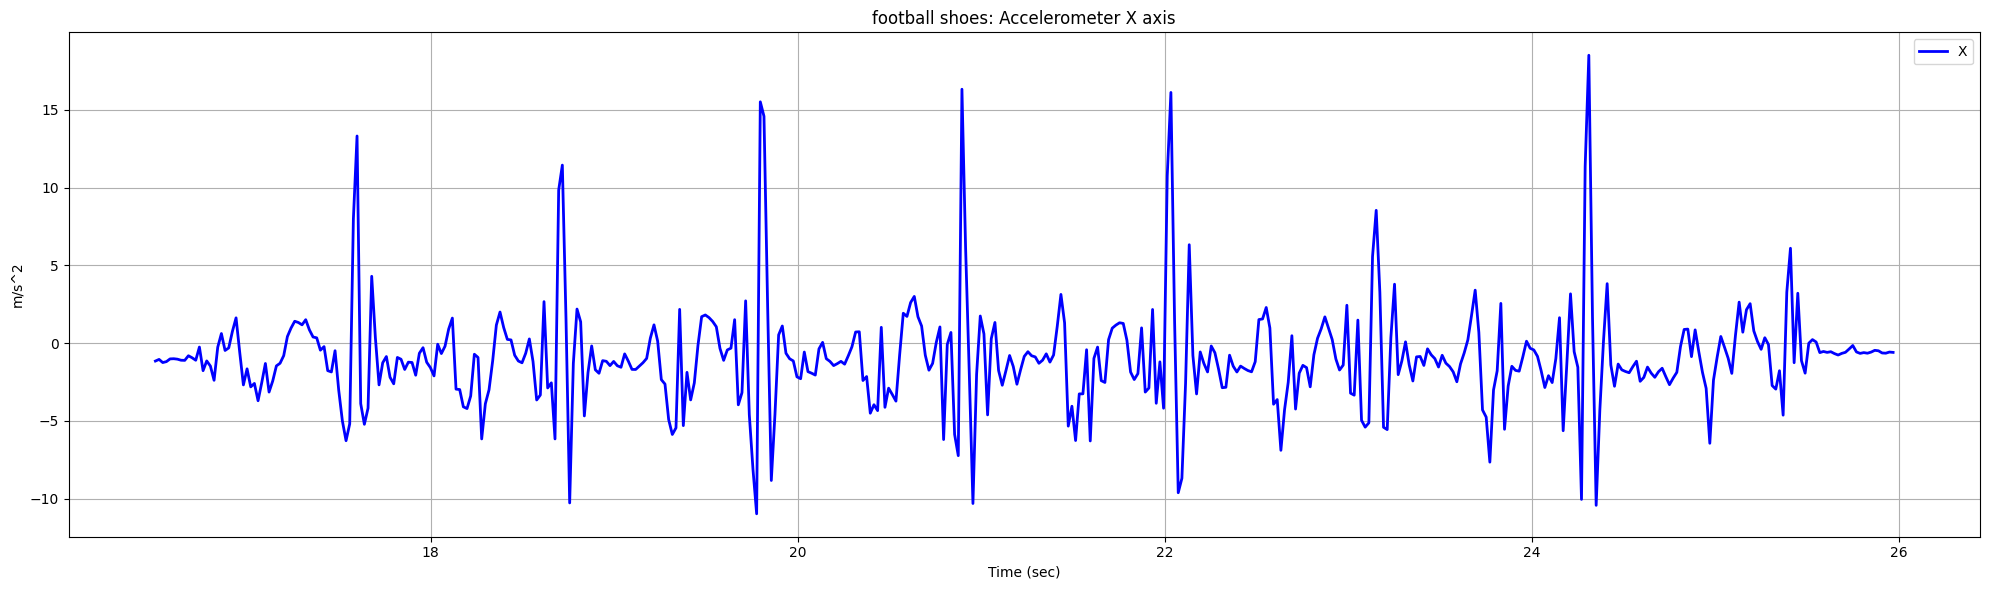

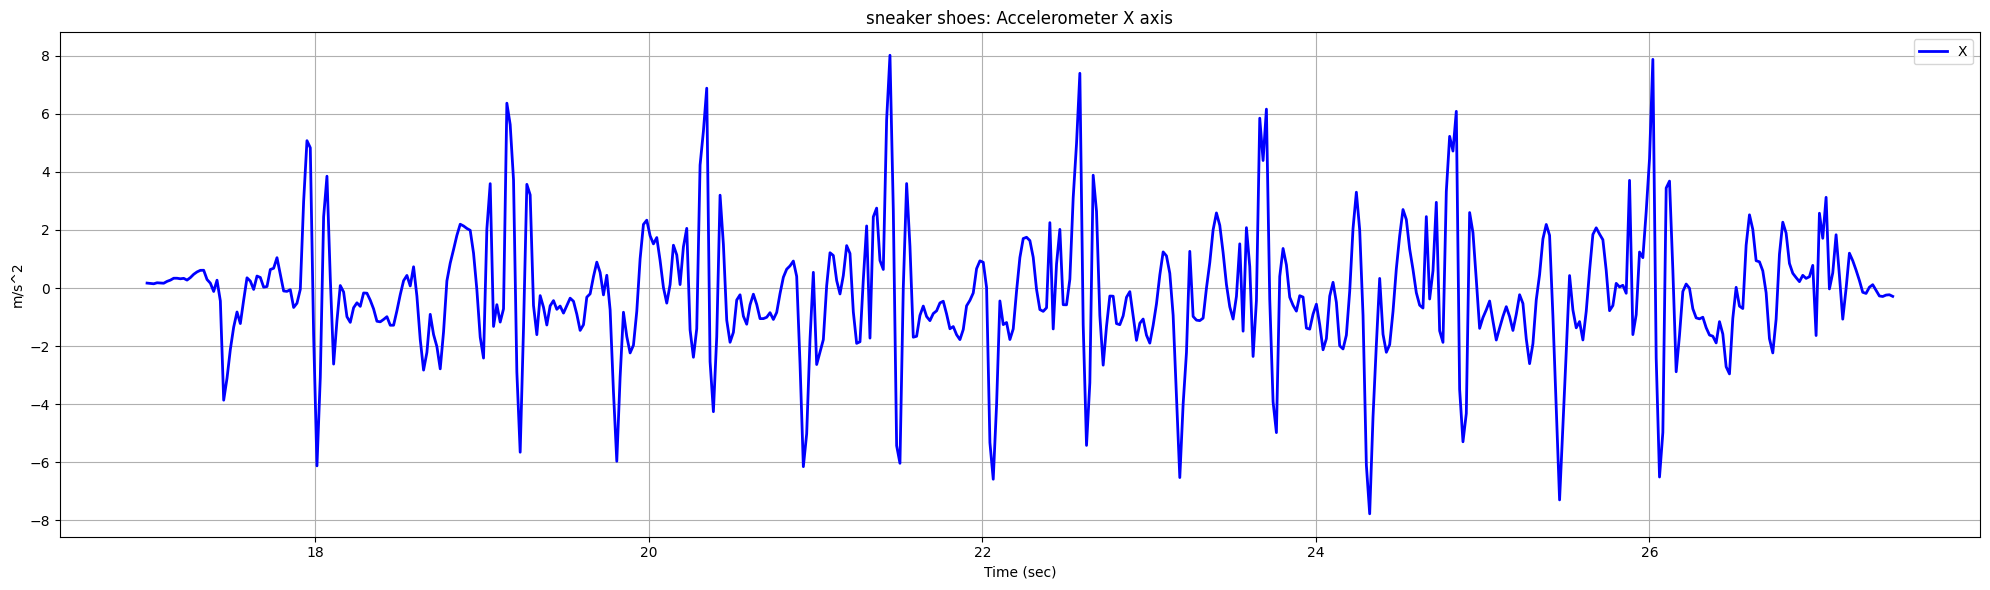

In [45]:
plot_data(football_shoes["time"], football_shoes, "Accelerometer", "X", "football")
plot_data(sneaker_shoes["time"], sneaker_shoes, "Accelerometer", "X", "sneaker")

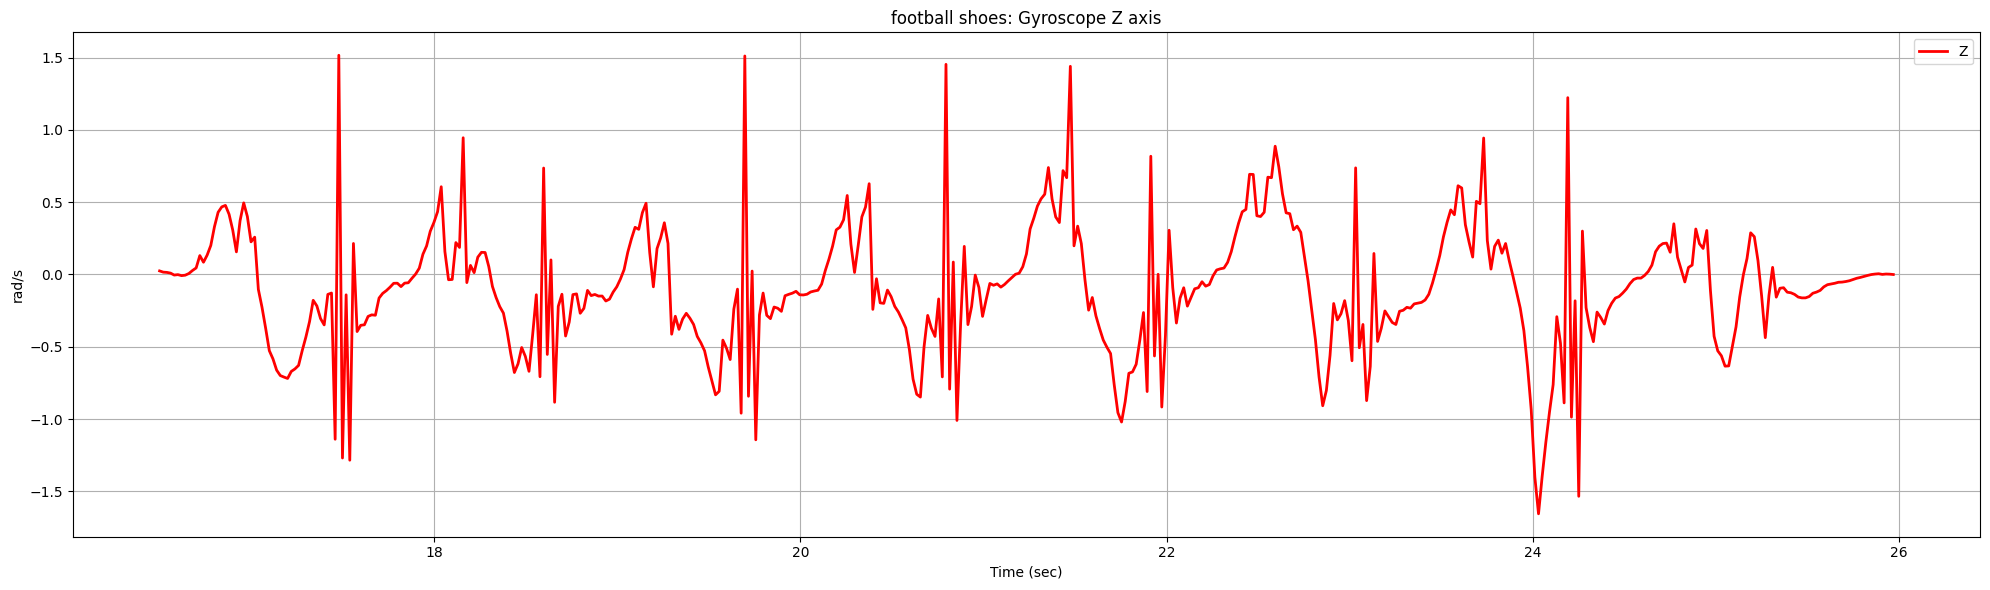

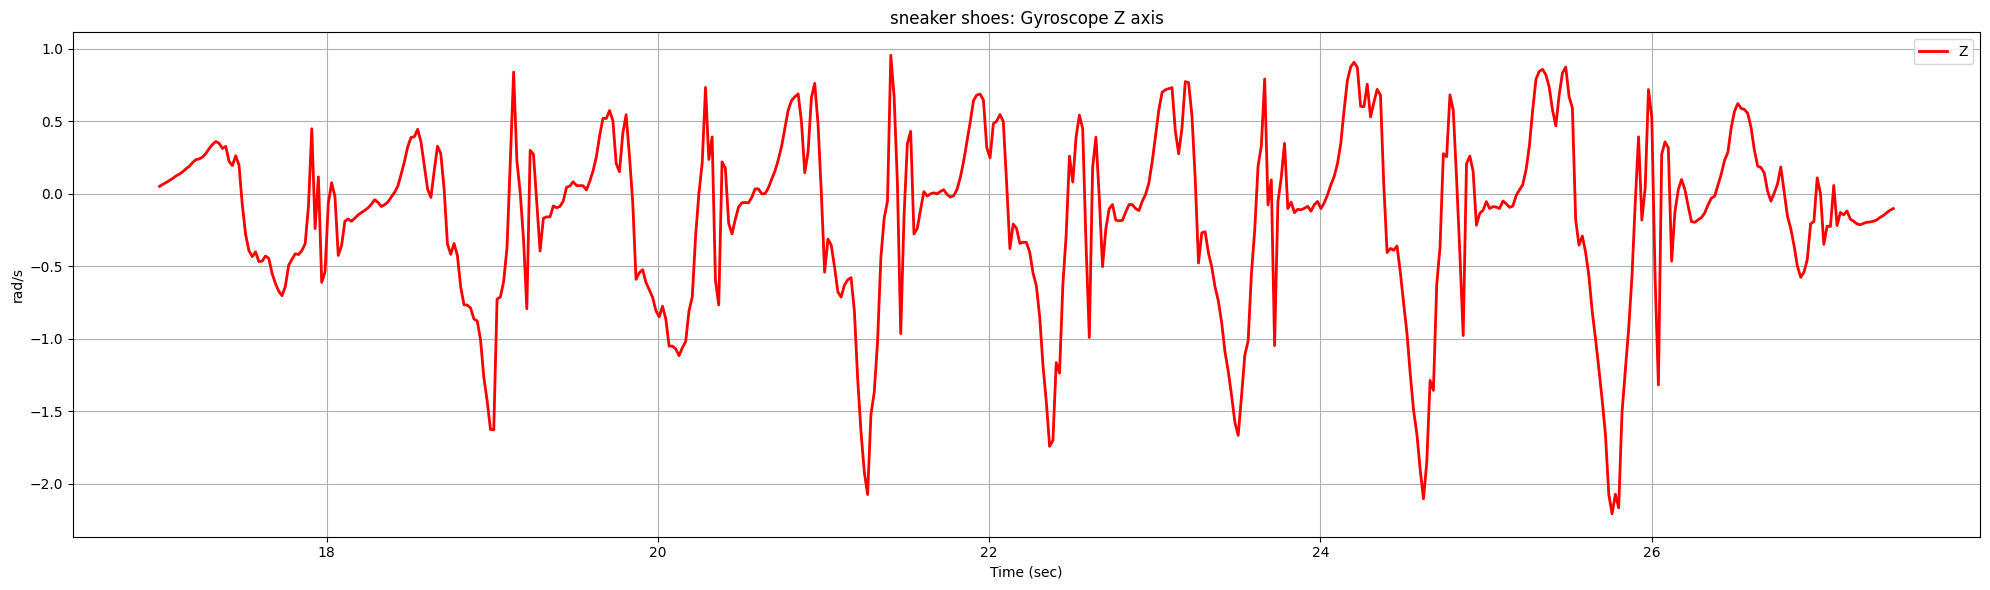

In [46]:
plot_data(football_shoes["time"], football_shoes, "Gyroscope", "Z", "football")
plot_data(sneaker_shoes["time"], sneaker_shoes, "Gyroscope", "Z", "sneaker")

This are the plot of the raw data right as they were acquired. In fact, as we can see, there is a lot of noise all over the signal and it's jagged as well.

### Filtering the Accelerometer records

In [47]:
from scipy.ndimage import gaussian_filter
filtered_x_axis = gaussian_filter(football_shoes["x_axis"], sigma=1.1)
filtered_y_axis = gaussian_filter(football_shoes["y_axis"], sigma=1.1)
filtered_z_axis = gaussian_filter(football_shoes["z_axis"], sigma=1)
football_filtered ={
    "x_axis": filtered_x_axis,
    "y_axis": filtered_y_axis,
    "z_axis": filtered_z_axis,
    "g_x_axis": g_x_axis, # yet to be filtered
    "g_y_axis": g_y_axis, # yet to be filtered
    "g_z_axis": g_z_axis # yet to be filtered
}

filtered_x_axis = gaussian_filter(sneaker_shoes["x_axis"], sigma=1.0)
filtered_y_axis = gaussian_filter(sneaker_shoes["y_axis"], sigma=1.4)
filtered_z_axis = gaussian_filter(sneaker_shoes["z_axis"], sigma=1.2)
sneaker_filtered ={
    "x_axis": filtered_x_axis,
    "y_axis": filtered_y_axis,
    "z_axis": filtered_z_axis,
    "g_x_axis": g_x_axis, # yet to be filtered
    "g_y_axis": g_y_axis, # yet to be filtered
    "g_z_axis": g_z_axis # yet to be filtered
}


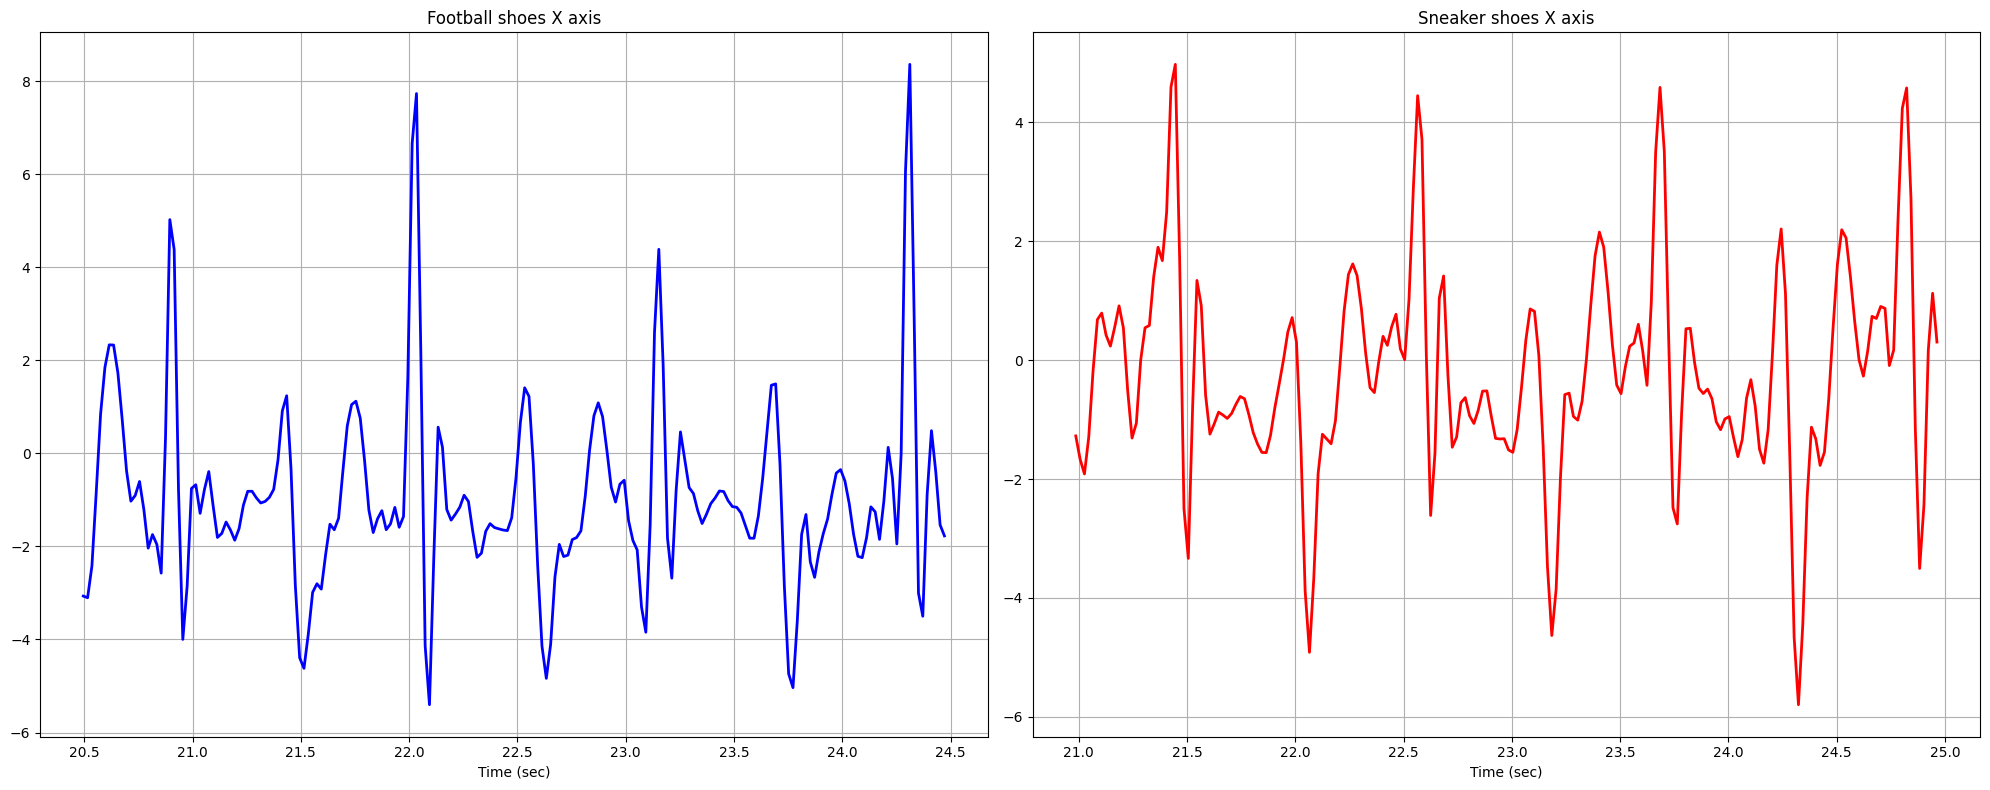

In [48]:
plt.figure(figsize=(20,8))
plt.subplot(1, 2, 1)
plt.plot(football_shoes["time"][200:400], football_filtered["x_axis"][200:400], color='b' , label="X", linewidth=2)
plt.title("Football shoes X axis")
plt.xlabel("Time (sec)")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(sneaker_shoes["time"][200:400], sneaker_filtered["x_axis"][200:400], color='r' , label="X", linewidth=2)
plt.title("Sneaker shoes X axis")
plt.xlabel("Time (sec)")
plt.grid()
plt.tight_layout()


### Analysis of the results obtained
The filter used is a Gaussian filter, wich allows to smooth the signal but it didn't highlight the spike. The obtained results, all things consedered, are good. In fact the usage of other filter, such as Butterworth produces a wrong output, expetially for the Y axis.    
Therefore the decision was to use a Gaussian filter wich provides a coerent view of what I was expecting.
There aren't many differences from both signal but it's possible to note that while wearing football shoes the peaks of X values are higher. This happens due to the cleats under the football shoes. In fact, while walking wering football shoes, my foot tends to "move" outwards.

### Filtering the Gyroscope readings

In [49]:
from scipy import signal

# Omissibile
football_ankle_x_fft = np.fft.fft(football_shoes["g_x_axis"])
football_ankle_y_fft = np.fft.fft(football_shoes["g_y_axis"])
football_ankle_z_fft = np.fft.fft(football_shoes["g_z_axis"])
football_n = football_ankle_z_fft.size
# 
freq = np.fft.fftfreq(football_n, 1/freq_sampling)

w = 5/(50/2)
b,a = signal.butter(1, w, btype="low")
filtered_x_axis = signal.lfilter(b, a, football_shoes["g_x_axis"])

w = 10/(50/2)
b,a = signal.butter(1, w, btype="low")
filtered_y_axis = signal.lfilter(b, a, football_shoes["g_y_axis"])

w = 8/(50/2)
b,a = signal.butter(1, w, btype="low")
filtered_z_axis = signal.lfilter(b, a, football_shoes["g_z_axis"])

football_filtered["g_x_axis"] = filtered_x_axis
football_filtered["g_y_axis"] = filtered_y_axis
football_filtered["g_z_axis"] = filtered_z_axis

w = 11/(50/2)
b,a = signal.butter(1, w, btype="low")
filtered_x_axis = signal.lfilter(b, a, sneaker_shoes["g_x_axis"])

w = 5/(50/2)
b,a = signal.butter(1, w, btype="low")
filtered_y_axis = signal.lfilter(b, a, sneaker_shoes["g_y_axis"])

w = 8/(50/2)
b,a = signal.butter(1, w, btype="low")
filtered_z_axis = signal.lfilter(b, a, sneaker_shoes["g_z_axis"])

sneaker_filtered["g_x_axis"] = filtered_x_axis
sneaker_filtered["g_y_axis"] = filtered_y_axis
sneaker_filtered["g_z_axis"] = filtered_z_axis

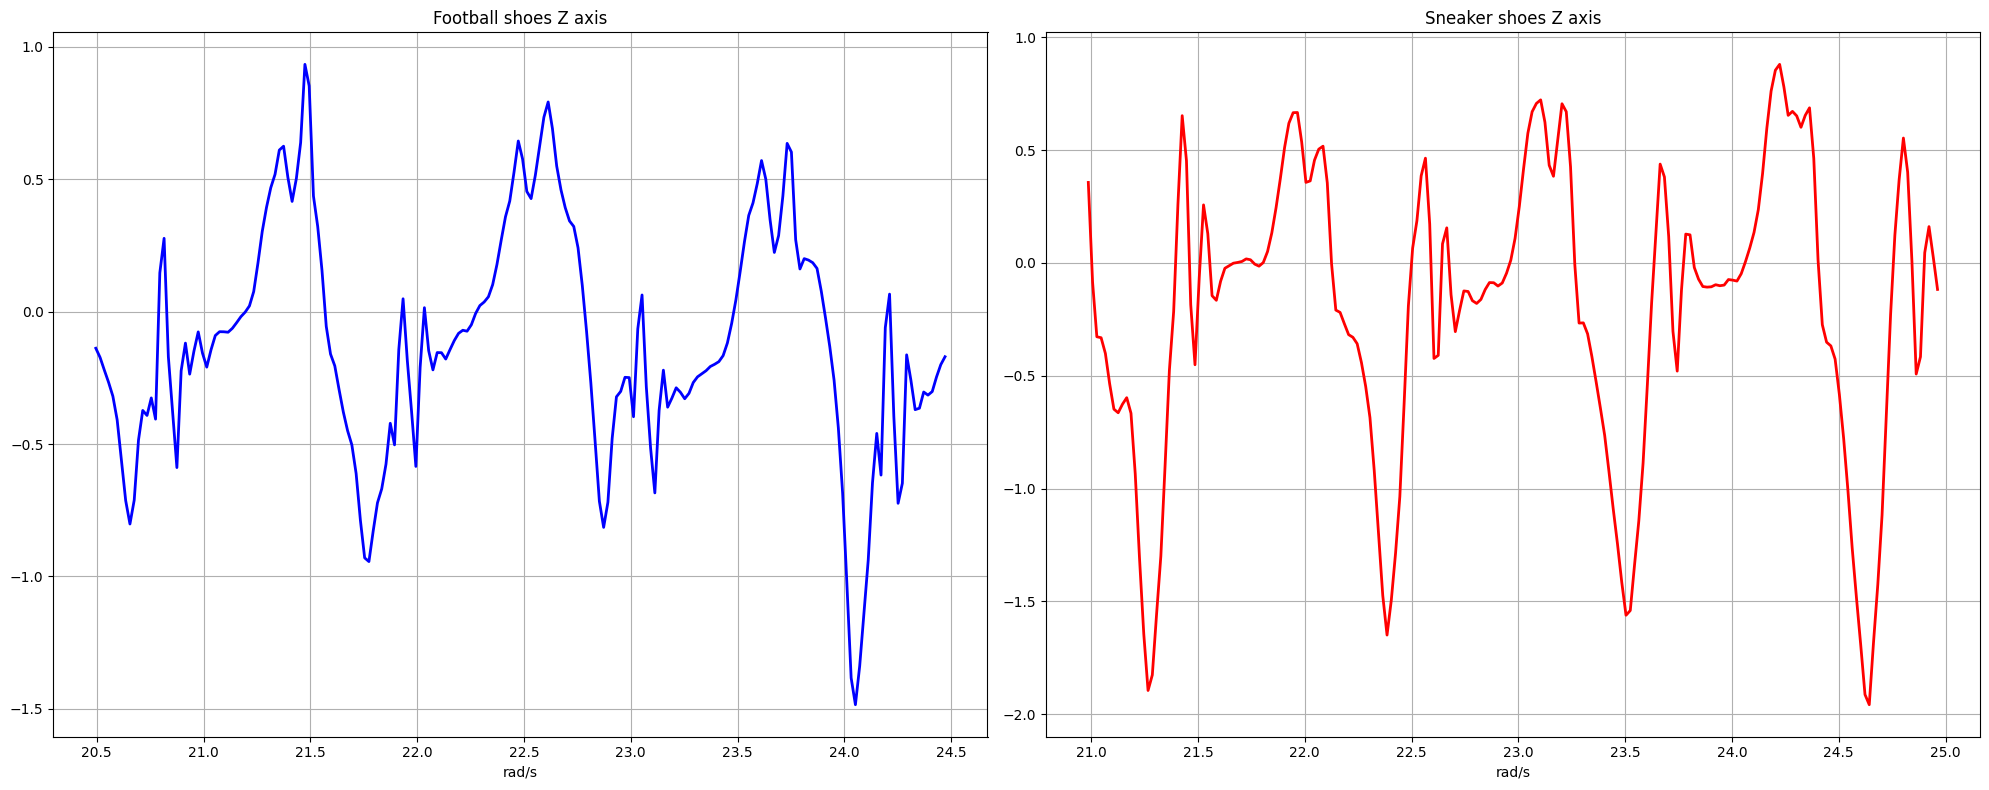

In [50]:
plt.figure(figsize=(20,8))
plt.subplot(1, 2, 1)
plt.plot(football_shoes["time"][200:400], football_filtered["g_z_axis"][200:400], color='b', linewidth=2)
plt.title("Football shoes Z axis")
plt.grid()
plt.xlabel("rad/s")

plt.subplot(1, 2, 2)
plt.plot(sneaker_shoes["time"][200:400], sneaker_filtered["g_z_axis"][200:400], color='r', linewidth=2)
plt.title("Sneaker shoes Z axis")
plt.xlabel("rad/s")
plt.grid()
plt.tight_layout()

### Analysis of the results obtained
As we can see the filtered signal for the X axis are very similar. however the signal for the Y and Z axis presents some differences.    
All the signal recorded while wearing football shoes are less smooth, even after the filtering process.
Indeed the seegnal for the Z axis, with football shoes, has higher and thinner spike. This is due to the cleats wich make every step feel more "robotic".
As expected the Z axis highlights that, with football, shoes my foot tends to outwards during steps and, on the other way, with sneakers, the foot roteates inside instead.

### Onorable mention

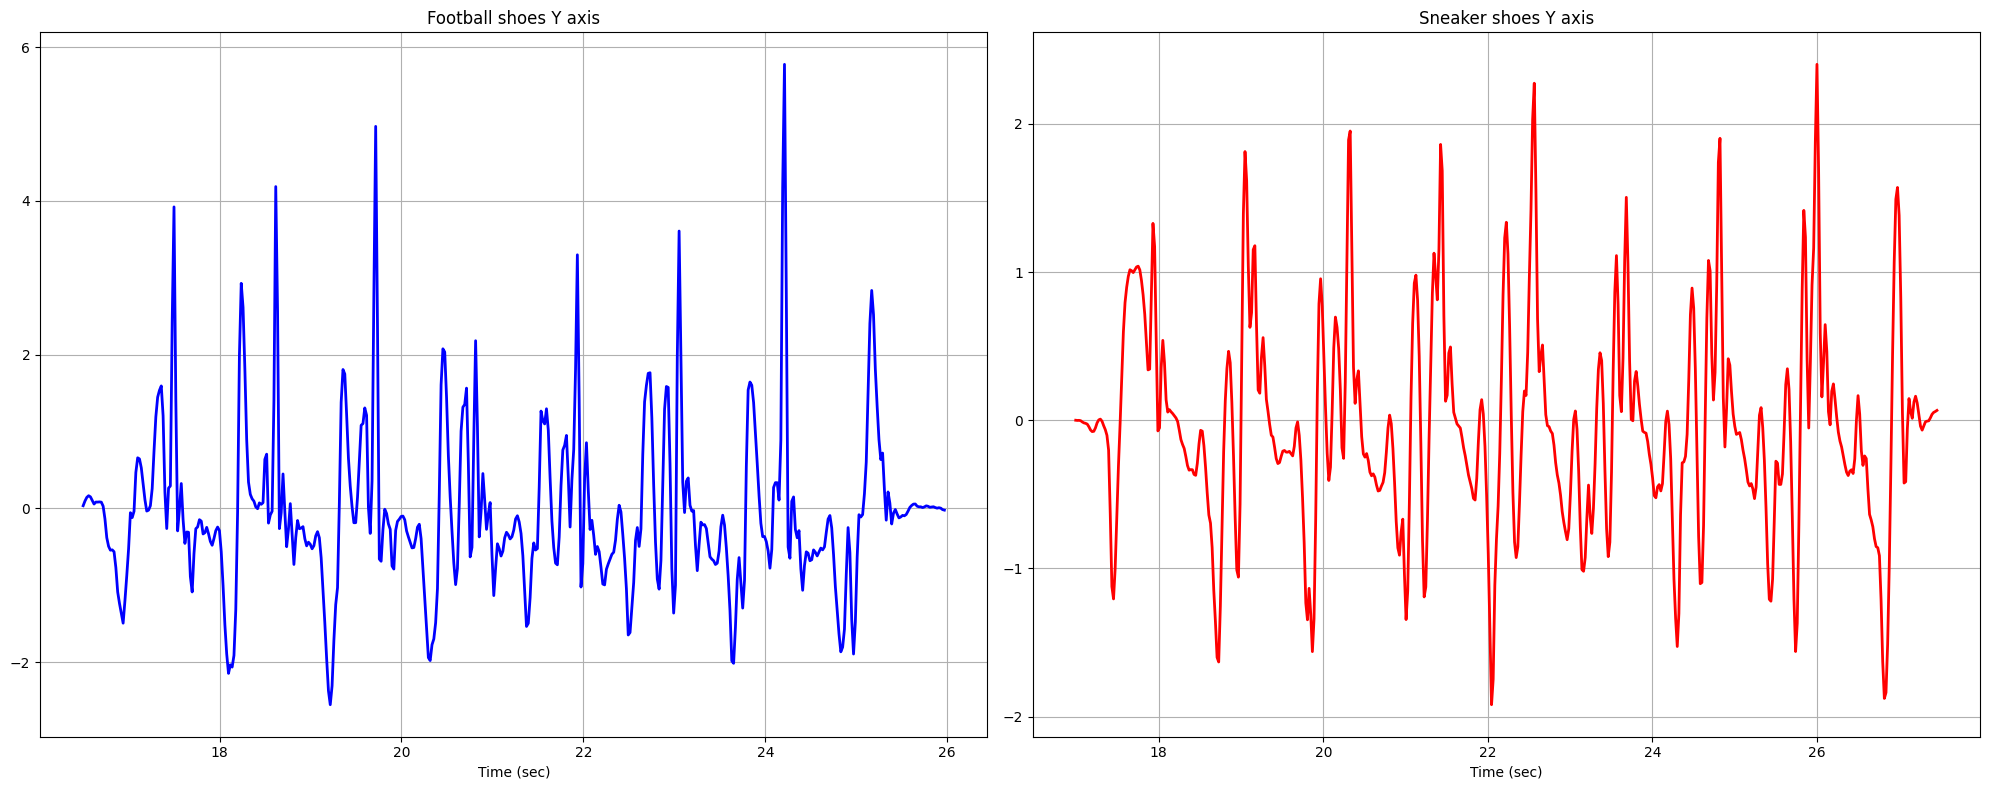

In [51]:
plt.figure(figsize=(20,8))
plt.subplot(1, 2, 1)
plt.plot(football_shoes["time"], football_filtered["g_y_axis"], color='b' , label="X", linewidth=2)
plt.title("Football shoes Y axis")
plt.xlabel("Time (sec)")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(sneaker_shoes["time"], sneaker_filtered["g_y_axis"], color='r' , label="X", linewidth=2)
plt.title("Sneaker shoes Y axis")
plt.xlabel("Time (sec)")
plt.grid()
plt.tight_layout()

These graph shows that the rotation given by the football shoes, throught the Y axis, is at least twice the one given wearing the sneaker.

### Jerk analysis

In [52]:
football_jerk = {
    "x_axis":np.diff(football_filtered["x_axis"]),
    "y_axis":np.diff(football_filtered["y_axis"]),
    "z_axis":np.diff(football_filtered["z_axis"])
}

sneaker_jerk = {
    "x_axis":np.diff(sneaker_filtered["x_axis"]),
    "y_axis":np.diff(sneaker_filtered["y_axis"]),
    "z_axis":np.diff(sneaker_filtered["z_axis"])
}

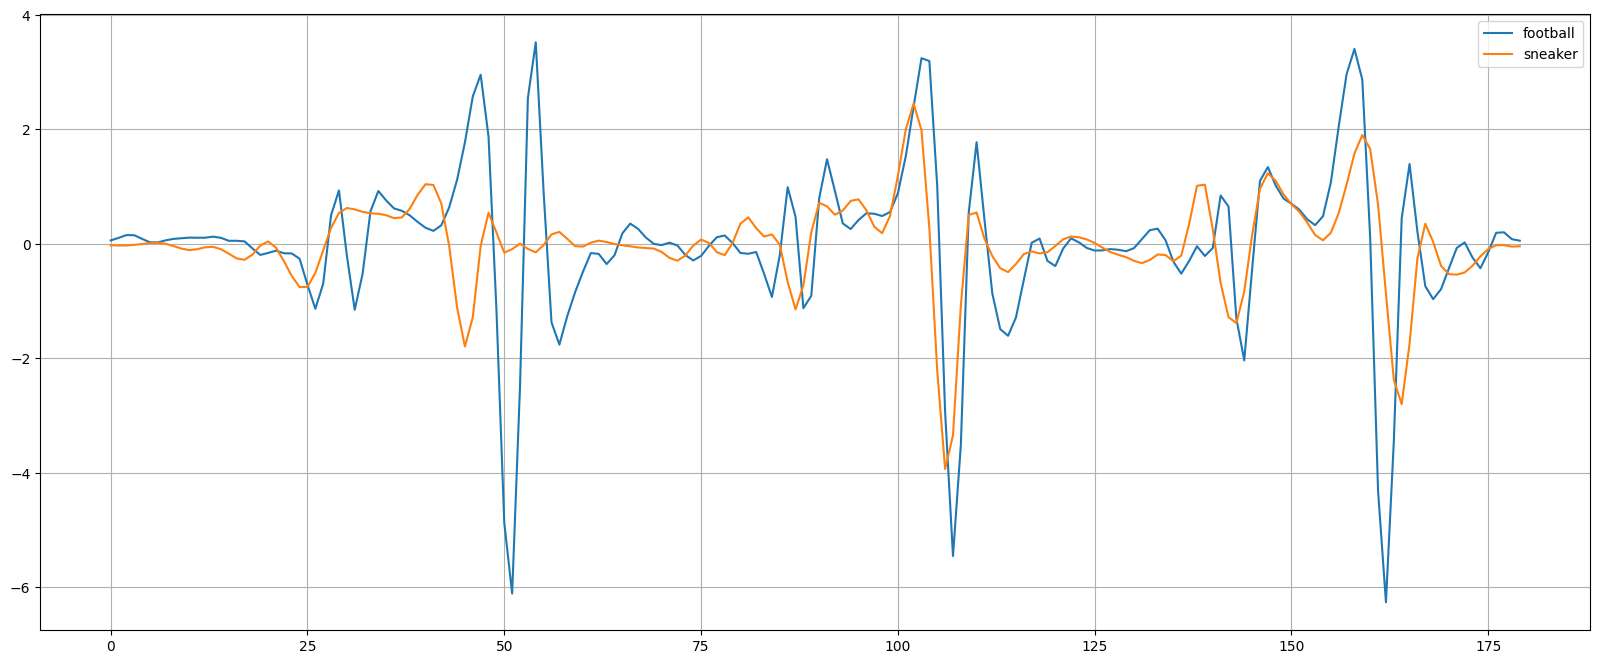

In [53]:
sneaker_x_jerk = gaussian_filter(sneaker_jerk["x_axis"], sigma=1)
sneaker_y_jerk = gaussian_filter(sneaker_jerk["y_axis"], sigma=1.2)
sneaker_z_jerk = gaussian_filter(sneaker_jerk["z_axis"], sigma=1)

football_x_jerk = gaussian_filter(football_jerk["x_axis"], sigma=1.2)
football_y_jerk = gaussian_filter(football_jerk["y_axis"], sigma=1.2)
football_z_jerk = gaussian_filter(football_jerk["z_axis"], sigma=1)

plt.figure(figsize=(20,8))
plt.plot(football_z_jerk[:180])
plt.grid()
plt.plot(sneaker_z_jerk[:180])
plt.legend(['football', 'sneaker'])

Here is a small <i>Jerk</i> analysis.    
If we take a look at the graph we can realize that the Jerk with football shoes is higher. But what does it mean?   
The Jerk is a series of values ,which if they are lower it means that the variation, throught the time, of the kinematic parameters is regular. It's easy to see that with football shoes on the Jerk's values are higher wich is a singal for a irregular, and probably not natural, movement.

## Conclusion
What this notebook highlights is that there are some effective different between these two walking style.
In fact if we wear a pair of football shoes, due to the disposition of the cleats, the weight will be loaded only on the outer part of the foot.    
    This is the cause of the differences in the value between the two X axis for the accelerometer and Y and Z axis for the Gyroscope.         
Once again due to the cleats the jerk is different. Indeed the walk feels more innatural, with football shoeas, and the data confirm this observation.

## Further details

In this section there are the other experiments with it's considerations.   
Both of the experiments where made with the mobile phone in the rear pocket with the screen facing outside. Due to the position of the mobile, this data are less relevant for the project.

### Data loading

In [54]:
f_accelerometer = pd.read_csv('../data/football_shoes_walk/AccelerometerUncalibrated.csv')
f_gyroscope = pd.read_csv('../data/football_shoes_walk/GyroscopeUncalibrated.csv')
f_x_axis_2 = f_accelerometer["x"][725:1125]
f_y_axis_2 = f_accelerometer["y"][725:1125]
f_z_axis_2 = f_accelerometer["z"][725:1125]
f_time_2 = f_accelerometer["seconds_elapsed"][725:1125]

# probably to delete due to the position of the mobile
f_g_x_axis_2 = f_gyroscope["x"][725:1125]
f_g_y_axis_2 = f_gyroscope["y"][725:1125]
f_g_z_axis_2 = f_gyroscope["z"][725:1125]

football_shoes_2 = {
    "time": f_time_2,
    "x_axis": f_x_axis_2,
    "y_axis": f_y_axis_2,
    "z_axis": f_z_axis_2,
    "g_x_axis": f_g_x_axis_2,
    "g_y_axis": f_g_y_axis_2,
    "g_z_axis": f_g_z_axis_2,
}

In [55]:
accelerometer = pd.read_csv('../data/sneaker/AccelerometerUncalibrated.csv')
gyroscope = pd.read_csv('../data/sneaker/GyroscopeUncalibrated.csv')
x_axis_2 = accelerometer["x"][600:1000]
y_axis_2 = accelerometer["y"][600:1000]
z_axis_2 = accelerometer["z"][600:1000]
time_2 = accelerometer["seconds_elapsed"][600:1000]

# probably to delete due to the position of the mobile
g_x_axis_2 = gyroscope["x"][600:1000]
g_y_axis_2 = gyroscope["y"][600:1000]
g_z_axis_2 = gyroscope["z"][600:1000]

sneaker_shoes_2 = {
    "time": time_2,
    "x_axis": x_axis_2,
    "y_axis": y_axis_2,
    "z_axis": z_axis_2,
    "g_x_axis": g_x_axis_2,
    "g_y_axis": g_y_axis_2,
    "g_z_axis": g_z_axis_2,
}

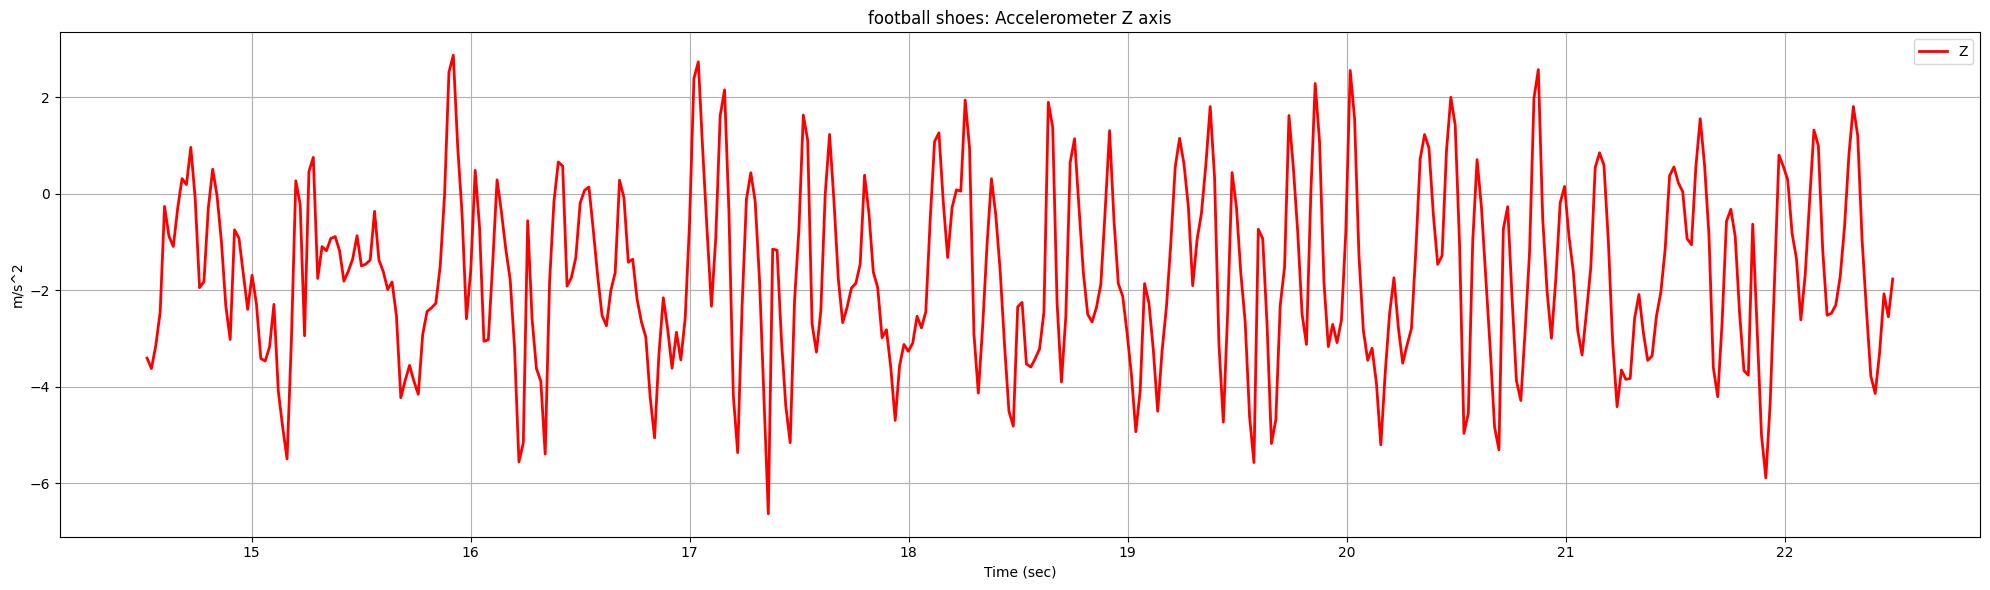

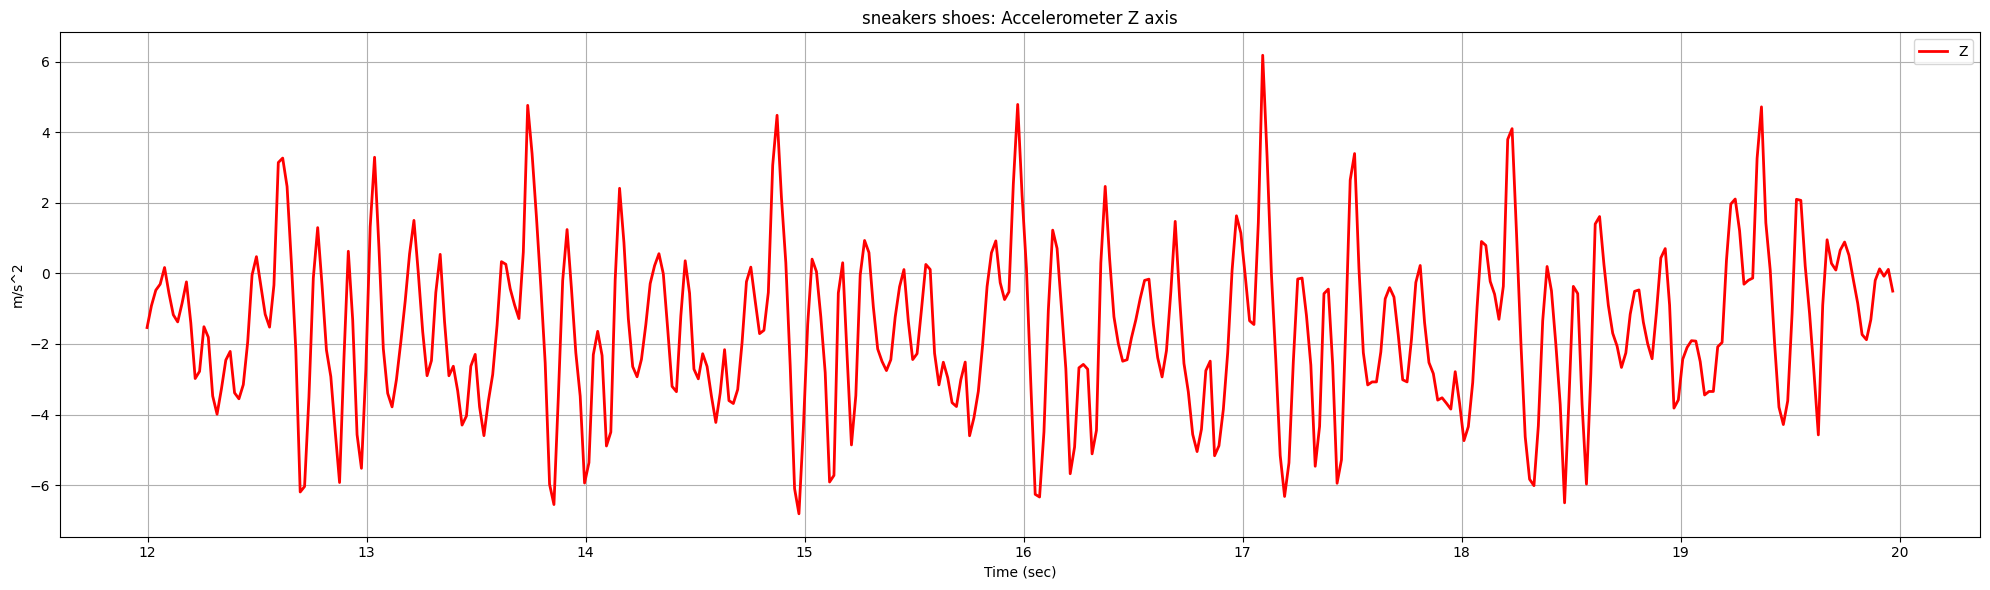

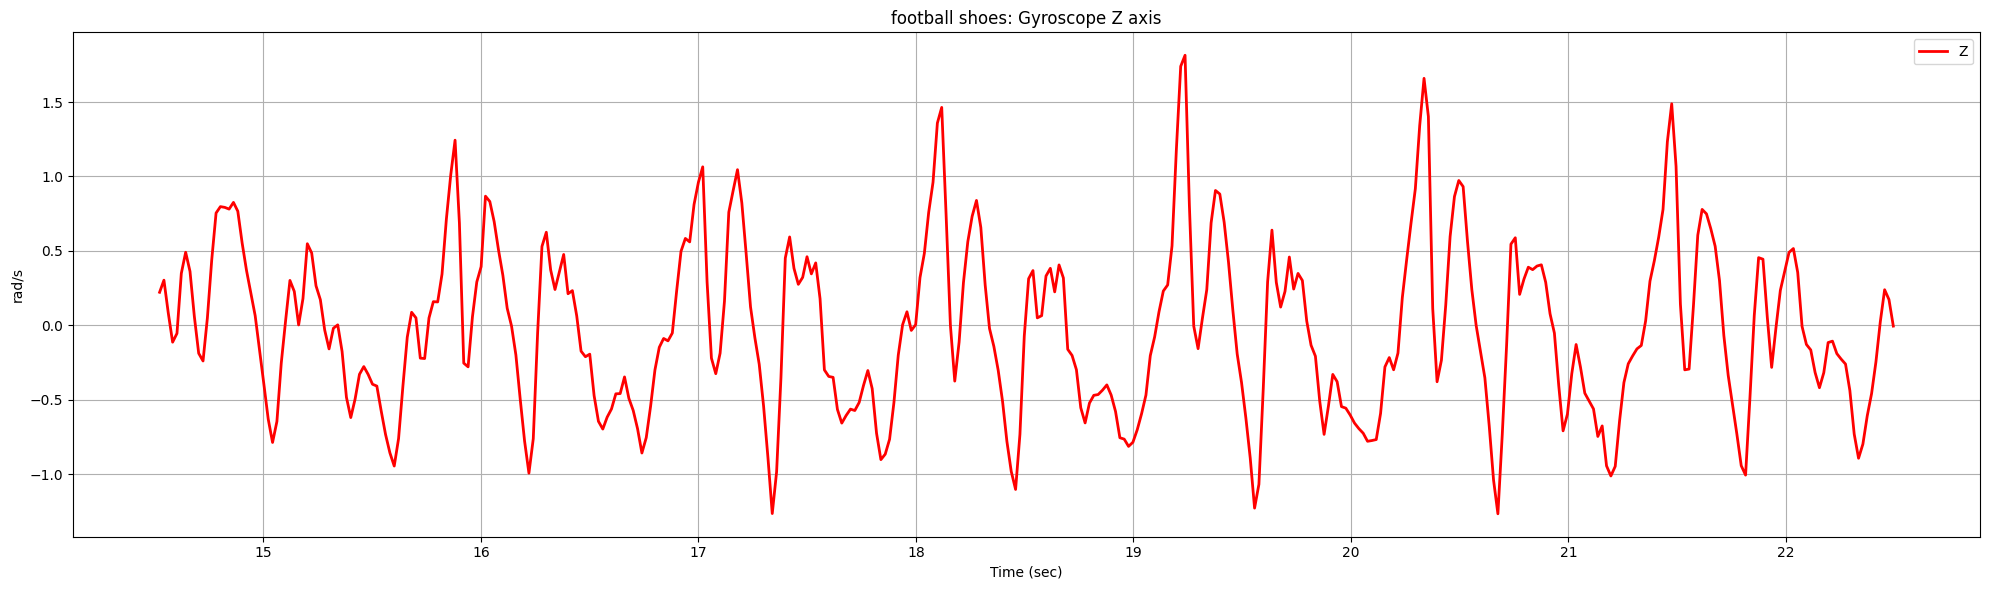

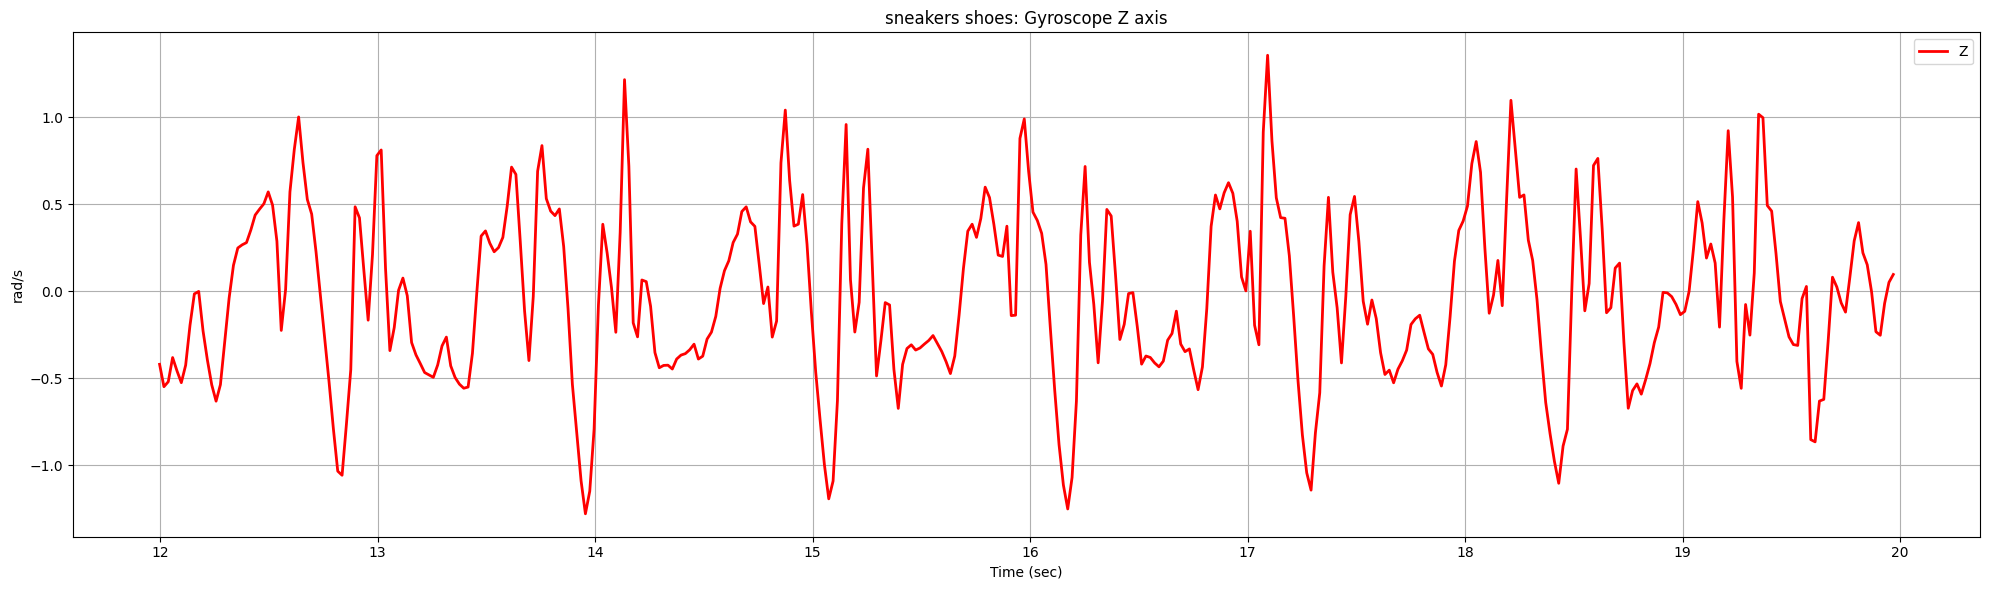

In [56]:
plot_data(football_shoes_2["time"],football_shoes_2, "Accelerometer", "Z", "football")
plot_data(sneaker_shoes_2["time"],sneaker_shoes_2, "Accelerometer", "Z", "sneakers")

plot_data(football_shoes_2["time"], football_shoes_2, "Gyroscope", "Z", "football")
plot_data(sneaker_shoes_2["time"], sneaker_shoes_2, "Gyroscope", "Z", "sneakers")


The axes that are plotted are the most relevant. In fact as me can see the value for the Z axis are twice higher while wearing the sneakers.    
I suppose that it happen because the foot is more stable an it allow to move the leg quickly.       
The values recorded with the Gyroscope aren't so much relevant. Indeed I suspect that the mobile phone wasn't so stable in the pocket.

### Filtering process

In [57]:
from scipy.ndimage import gaussian_filter

filtered_x_axis = gaussian_filter(sneaker_shoes_2["x_axis"], sigma=1)
filtered_y_axis = gaussian_filter(sneaker_shoes_2["y_axis"], sigma=1)
filtered_z_axis = gaussian_filter(sneaker_shoes_2["z_axis"], sigma=1.1)

g_filtered_x_axis = gaussian_filter(sneaker_shoes_2["x_axis"], sigma=1.1)
g_filtered_y_axis = gaussian_filter(sneaker_shoes_2["y_axis"], sigma=1)
g_filtered_z_axis = gaussian_filter(sneaker_shoes_2["z_axis"], sigma=1.3)

sneaker_filtered_2 ={
    "x_axis": filtered_x_axis,
    "y_axis": filtered_y_axis,
    "z_axis": filtered_z_axis,
    "g_x_axis": g_filtered_x_axis,
    "g_y_axis": g_filtered_y_axis,
    "g_z_axis": g_filtered_z_axis
}

filtered_x_axis = gaussian_filter(football_shoes_2["x_axis"], sigma=1.4)
filtered_y_axis = gaussian_filter(football_shoes_2["y_axis"], sigma=1.2)
filtered_z_axis = gaussian_filter(football_shoes_2["z_axis"], sigma=1.3)

g_filtered_x_axis = gaussian_filter(football_shoes_2["x_axis"], sigma=1.2)
g_filtered_y_axis = gaussian_filter(football_shoes_2["y_axis"], sigma=1.1)
g_filtered_z_axis = gaussian_filter(football_shoes_2["z_axis"], sigma=1)

football_filtered_2 ={
    "x_axis": filtered_x_axis,
    "y_axis": filtered_y_axis,
    "z_axis": filtered_z_axis,
    "g_x_axis": g_filtered_x_axis,
    "g_y_axis": g_filtered_y_axis,
    "g_z_axis": g_filtered_z_axis
}

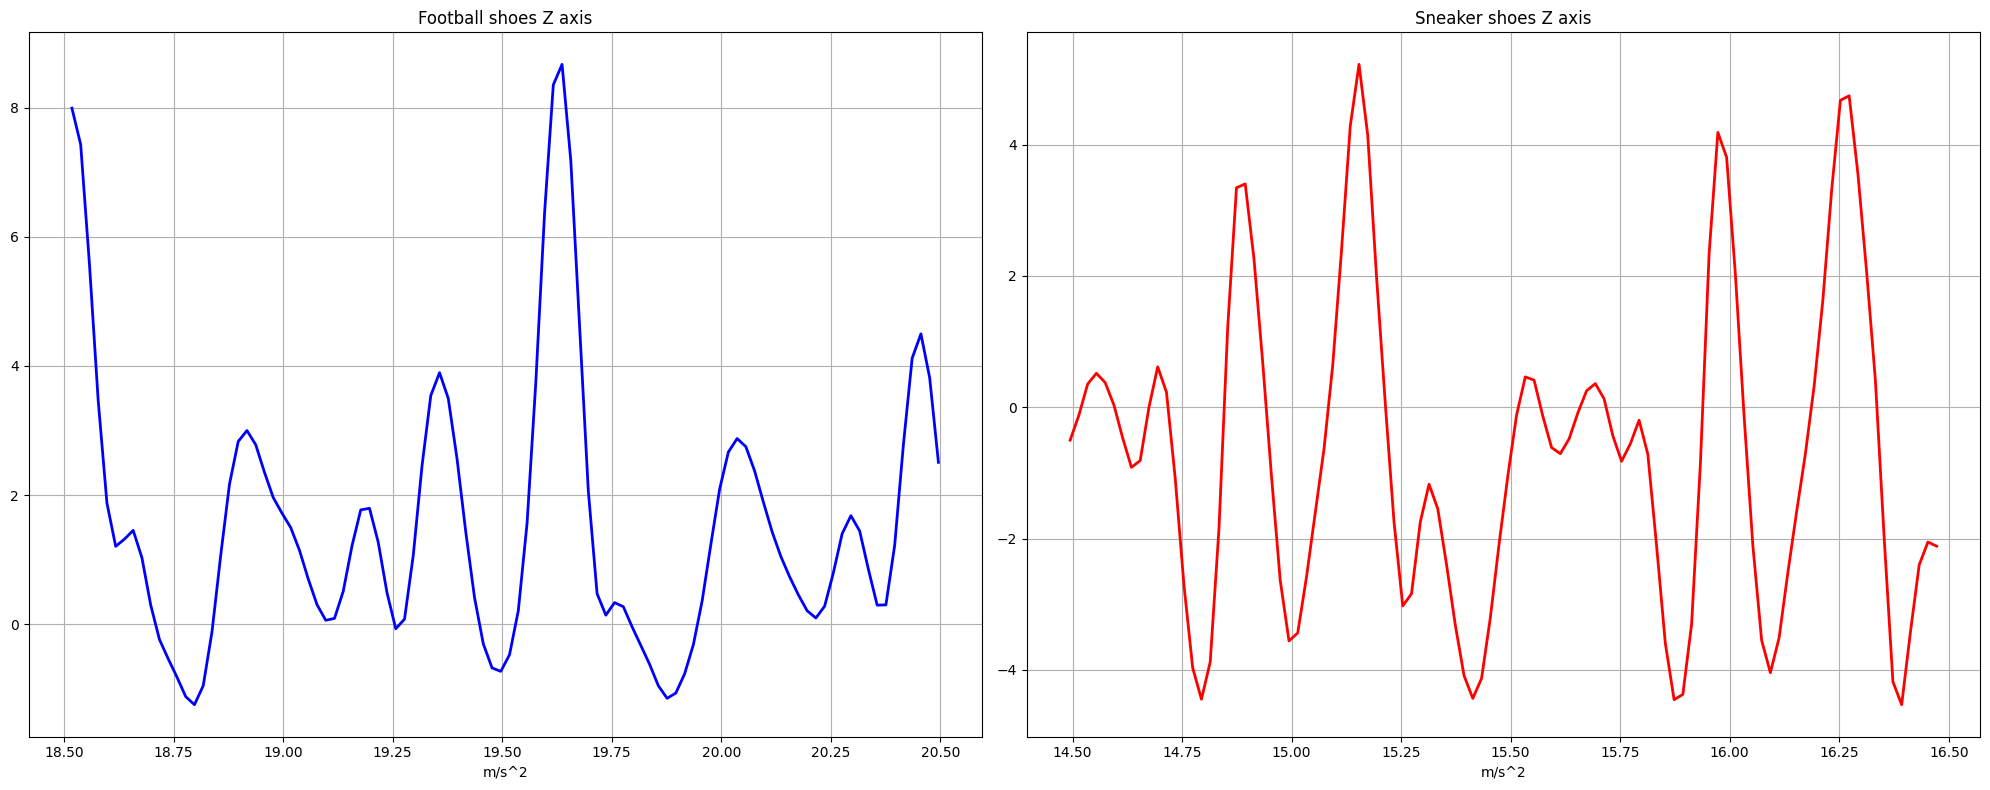

In [58]:
plt.figure(figsize=(20,8))
plt.subplot(1, 2, 1)
plt.plot(football_shoes_2["time"][200:300], football_filtered_2["x_axis"][200:300], color='b', linewidth=2)
plt.title("Football shoes Z axis")
plt.xlabel("m/s^2")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(sneaker_shoes_2["time"][125:225], sneaker_filtered_2["x_axis"][125:225], color='r', linewidth=2)
plt.title("Sneaker shoes Z axis")
plt.xlabel("m/s^2")
plt.grid()
plt.tight_layout()

#plt.figure(figsize=(20,8)
#plt.plot(sneaker_shoes_2["time"], sneaker_filtered_2["x_axis"], color='r', linewidth=2)
#plt.figure(figsize=(20,8))
#plt.plot(football_shoes_2["time"], football_filtered_2["x_axis"], color='r', linewidth=2)


#### Observation: 
The graph confirms, even with the mobile phone in the rear pocket, that the weight tends to the outer part of the foot.    
Indeed the value for the X axis while wearing football shoes, when it's positive, are twice the value wearing the sneaker.

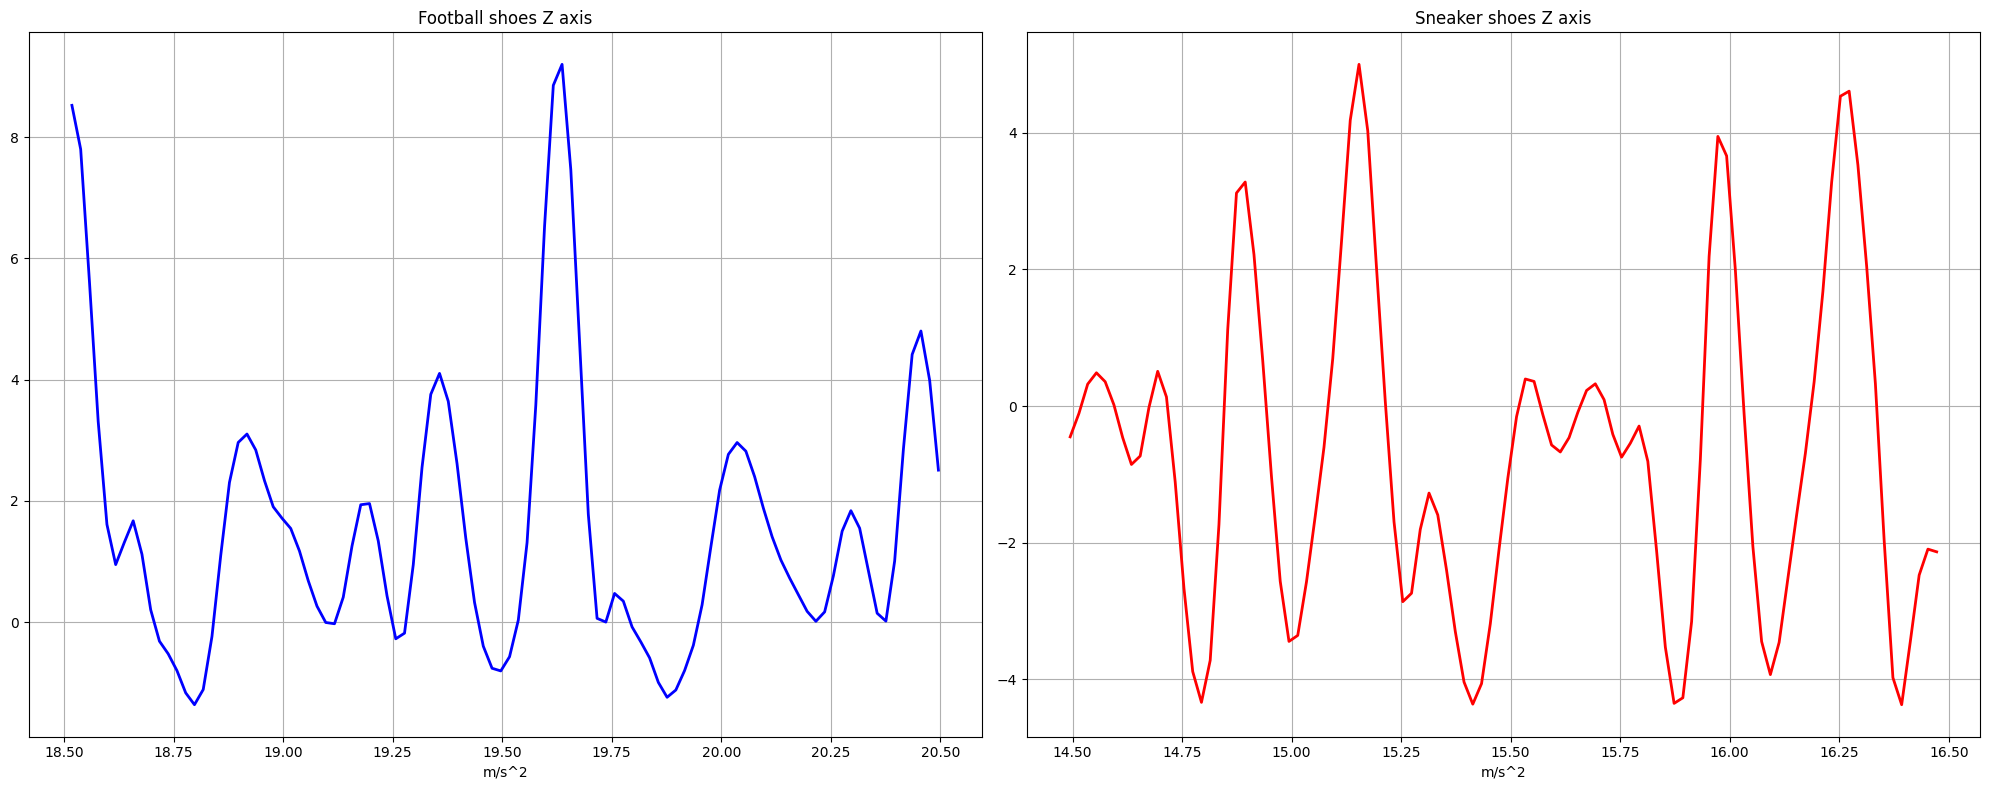

In [59]:
plt.figure(figsize=(20,8))
plt.subplot(1, 2, 1)
plt.plot(football_shoes_2["time"][200:300], football_filtered_2["g_x_axis"][200:300], color='b', linewidth=2)
plt.title("Football shoes Z axis")
plt.xlabel("m/s^2")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(sneaker_shoes_2["time"][125:225], sneaker_filtered_2["g_x_axis"][125:225], color='r', linewidth=2)
plt.title("Sneaker shoes Z axis")
plt.xlabel("m/s^2")
plt.grid()
plt.tight_layout()

#### Observation: 
Here ,unexpectedly, there are some differences. In fact the graph highlights that while wearing football shoes I rotate more along the X axis.
One possible explanation could be that the cleats makes you lift your leg more instead of sneaker. Therefore the walk feel more robotic as hypothesized at the beginng.